# RCWA 能力展示

用经典光学算例核对 RCWA：功率通量、衍射级、Maxwell 应力、层内能量、复频极点与 \(\varepsilon(x,y)\) 采样。

记号：\(f\) 以 \(c/a\) 计（\(a=1\)，\(\lambda=1/f\)）；\(R,T\) 为相对入射功率；无损时 \(R+T\approx 1\)；\(n_G\) 为傅里叶阶数；文中应力来自 Maxwell 应力张量，勿与透射 \(T\) 混淆。

若干小节附文献原图（见 `resources/`）与 DOI，便于对照物理结论；计算与出图均由本软件完成。

运行前：`source scripts/init-simulation-build-env.sh`，保证 artifact 中 `simulation` 可导入。


In [1]:
%matplotlib inline
import math
import os

import matplotlib.pyplot as plt
import numpy as np

BUILD = os.environ["SIMULATION_ARTIFACTS_DIR"]
import simulation as sim
import layer_visualizer as lv


def mat_eps(eps, name):
    return sim.share_material_d(sim.material_d.from_epsilon(eps, name))


def layer(eps, depth, name):
    lyr = sim.layer_d()
    lyr.background_material = mat_eps(eps, name)
    lyr.depth = float(depth)
    return lyr


def fresnel_power(n1, n2, theta1_deg, pol):
    th1 = math.radians(theta1_deg)
    s = n1 / n2 * math.sin(th1)
    if abs(s) > 1.0:
        return 1.0, 0.0
    th2 = math.asin(s)
    if pol == "s":
        r = (n1 * math.cos(th1) - n2 * math.cos(th2)) / (n1 * math.cos(th1) + n2 * math.cos(th2))
        t = (2 * n1 * math.cos(th1)) / (n1 * math.cos(th1) + n2 * math.cos(th2))
        R = abs(r) ** 2
        T = abs(t) ** 2 * (n2 * math.cos(th2)) / (n1 * math.cos(th1))
    else:
        r = (n2 * math.cos(th1) - n1 * math.cos(th2)) / (n2 * math.cos(th1) + n1 * math.cos(th2))
        t = (2 * n1 * math.cos(th1)) / (n2 * math.cos(th1) + n1 * math.cos(th2))
        R = abs(r) ** 2
        T = abs(t) ** 2 * (n2 * math.cos(th2)) / (n1 * math.cos(th1))
    return R, T


def local_minima(y):
    return [i for i in range(1, len(y) - 1) if y[i] < y[i - 1] and y[i] < y[i + 1]]


def fp_pole_imag():
    return abs(0.5 * math.log(1.0 / 3.0) / (2.0 * math.pi))


def show_stack_3d(layers, title="Filmstack 3D", cell=None):
    """Single 3D filmstack: extrude 2D patterns / slabs; clip native 3D shapes by depth."""
    ax = lv.plot_layers_3d(layers, title=title, show=False, cell_xy=cell)
    plt.show()
    return ax


print("BUILD =", BUILD)


BUILD = /home/like/repos/simulation_toykits/simulation_core/build


## 1. Fresnel 界面：功率随入射角


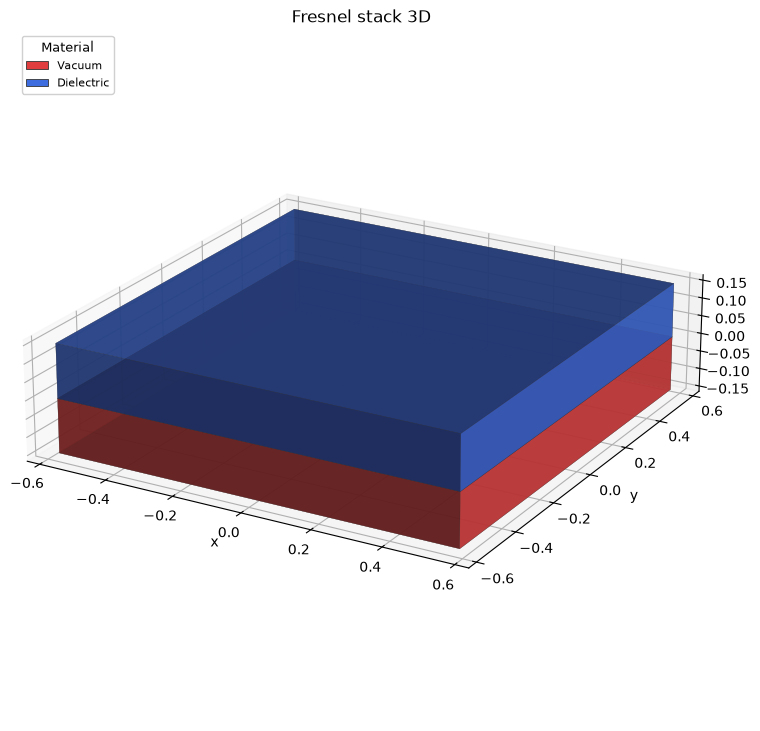

max |RCWA - Fresnel| = 1.033e-14; Brewster~63.4 deg, Rp=8.784e-05


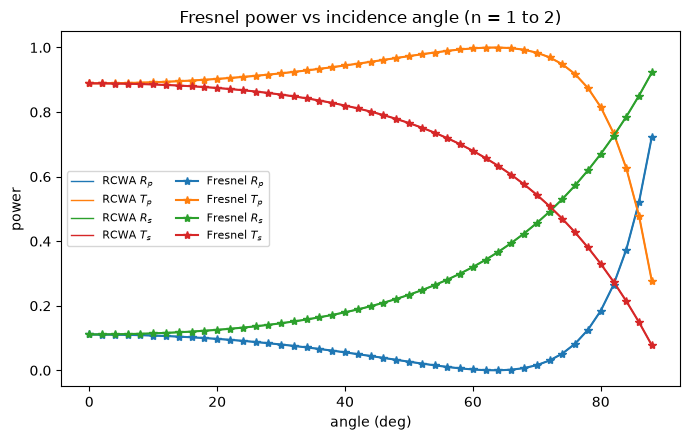

In [2]:
layers = [layer(1 + 0j, 0.0, "Vacuum"), layer(4 + 0j, 0.0, "Dielectric")]
show_stack_3d(layers, title="Fresnel stack 3D")

wl = 1.0
angles = np.arange(0, 89, 2, dtype=float)
Rp, Tp, Rs, Ts = [], [], [], []
Rp_ref, Tp_ref, Rs_ref, Ts_ref = [], [], [], []
max_err = 0.0
for ang in angles:
    inc_p, back_p = sim.rcwa_poynting_flux_d(layers, wl, n_G=1, theta_deg=float(ang), pol="p", which_layer=0)
    fwd_p, _ = sim.rcwa_poynting_flux_d(layers, wl, n_G=1, theta_deg=float(ang), pol="p", which_layer=1)
    inc_s, back_s = sim.rcwa_poynting_flux_d(layers, wl, n_G=1, theta_deg=float(ang), pol="s", which_layer=0)
    fwd_s, _ = sim.rcwa_poynting_flux_d(layers, wl, n_G=1, theta_deg=float(ang), pol="s", which_layer=1)
    rp = float(np.real(-back_p / inc_p)); tp = float(np.real(fwd_p / inc_p))
    rs = float(np.real(-back_s / inc_s)); ts = float(np.real(fwd_s / inc_s))
    Rp.append(rp); Tp.append(tp); Rs.append(rs); Ts.append(ts)
    rR, rT = fresnel_power(1.0, 2.0, float(ang), "p")
    sR, sT = fresnel_power(1.0, 2.0, float(ang), "s")
    Rp_ref.append(rR); Tp_ref.append(rT); Rs_ref.append(sR); Ts_ref.append(sT)
    max_err = max(max_err, abs(rp - rR), abs(tp - rT), abs(rs - sR), abs(ts - sT))

brewster = math.degrees(math.atan(2.0))
i_b = int(np.argmin(np.abs(angles - brewster)))
print(f"max |RCWA - Fresnel| = {max_err:.3e}; Brewster~{brewster:.1f} deg, Rp={Rp[i_b]:.3e}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(angles, Rp, "C0-", lw=1.0, label="RCWA $R_p$", zorder=1)
ax.plot(angles, Tp, "C1-", lw=1.0, label="RCWA $T_p$", zorder=1)
ax.plot(angles, Rs, "C2-", lw=1.0, label="RCWA $R_s$", zorder=1)
ax.plot(angles, Ts, "C3-", lw=1.0, label="RCWA $T_s$", zorder=1)
ax.plot(angles, Rp_ref, "C0-*", lw=1.5, label="Fresnel $R_p$", zorder=2)
ax.plot(angles, Tp_ref, "C1-*", lw=1.5, label="Fresnel $T_p$", zorder=2)
ax.plot(angles, Rs_ref, "C2-*", lw=1.5, label="Fresnel $R_s$", zorder=2)
ax.plot(angles, Ts_ref, "C3-*", lw=1.5, label="Fresnel $T_s$", zorder=2)
ax.set_xlabel("angle (deg)")
ax.set_ylabel("power")
ax.set_title("Fresnel power vs incidence angle (n = 1 to 2)")
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
plt.show()


核对：实线（RCWA）与虚线（Fresnel）应对齐；各偏振 \(R+T\approx 1\)；Brewster 角约 \(63.4^\circ\) 处 \(R_p\to 0\)，\(R_s\) 不消。


## 2. Fabry–Perot 平板：透射谱与层内电场能量


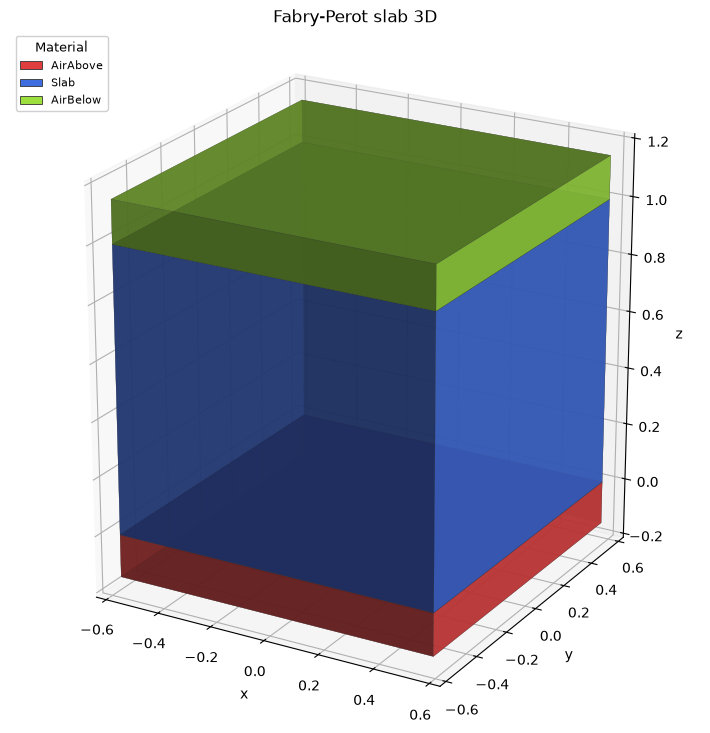

T in [0.640, 1.000], corr(T, energy)=0.893


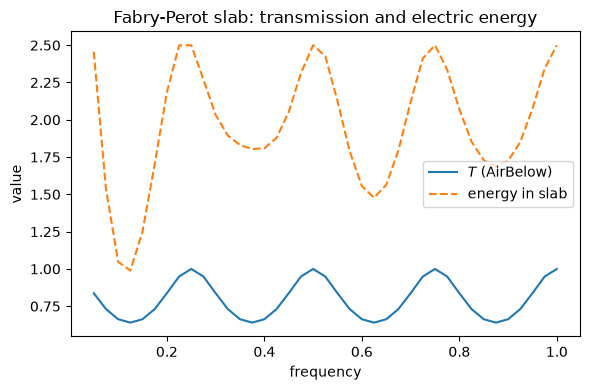

In [3]:
layers = [
    layer(1 + 0j, 0.0, "AirAbove"),
    layer(4 + 0j, 1.0, "Slab"),
    layer(1 + 0j, 0.0, "AirBelow"),
]
show_stack_3d(layers, title="Fabry-Perot slab 3D")

freqs = np.arange(0.05, 1.001, 0.025)
T, E2 = [], []
for f in freqs:
    wl = 1.0 / float(f)
    fwd, _ = sim.rcwa_poynting_flux_d(layers, wl, n_G=1, pol="p", which_layer=2)
    e = sim.rcwa_layer_electric_energy_d(layers, wl, n_G=1, pol="p", which_layer=1)
    T.append(float(np.real(fwd)))
    E2.append(float(np.real(e)))
T = np.asarray(T)
E2 = np.asarray(E2)
print(f"T in [{T.min():.3f}, {T.max():.3f}], corr(T, energy)={np.corrcoef(T, E2)[0,1]:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(freqs, T, "C0-", label="$T$ (AirBelow)")
ax.plot(freqs, E2, "C1--", label=r"energy in slab")
ax.set_xlabel("frequency")
ax.set_ylabel("value")
ax.set_title("Fabry-Perot slab: transmission and electric energy")
ax.legend()
fig.tight_layout()
plt.show()


核对：\(T(f)\) 随频率起伏；板内电场能量应与 \(T\) 同起同落（相关高即可，量纲不同）。


## 3. 光子晶体板中的导共鸣振（Fan 结构）


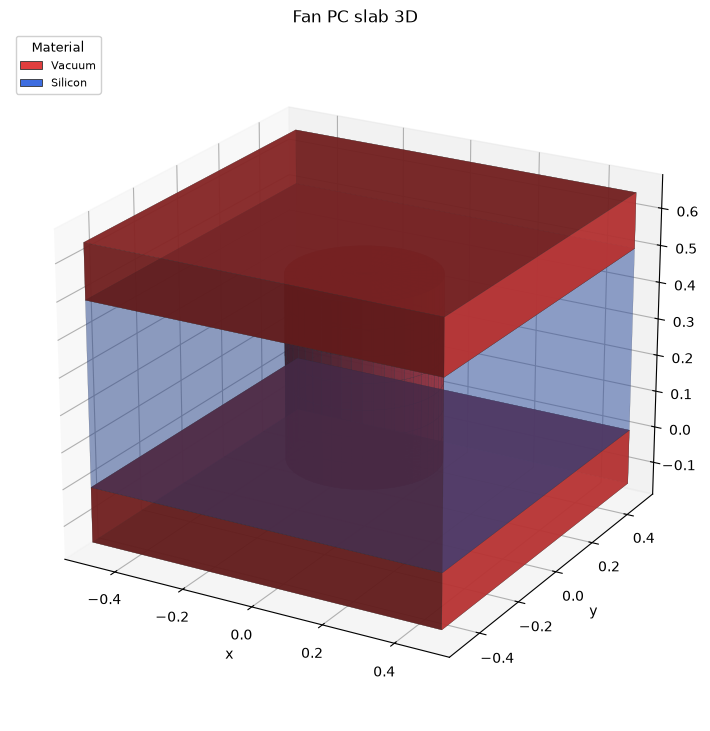

/tmp/ipykernel_35880/2909134179.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


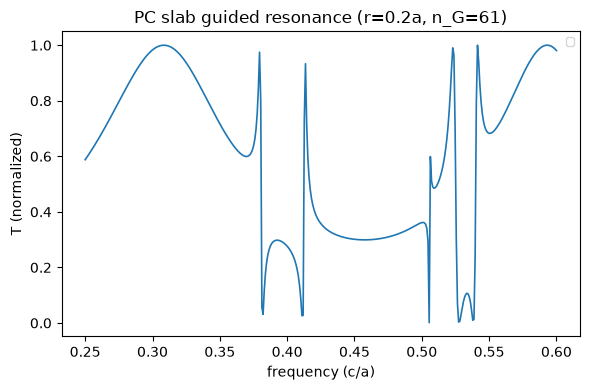

In [4]:
n_G = 61
air = mat_eps(1 + 0j, "Vacuum")
si = mat_eps(12 + 0j, "Silicon")
above = sim.layer_d(); above.background_material = air; above.depth = 0.0
slab = sim.layer_d(); slab.background_material = si; slab.depth = 0.5
slab.shapes = [sim.make_circle_shape_d(0.2, [0.0, 0.0], 0.0, air)]
slab.parent = [-1]
below = sim.layer_d(); below.background_material = air; below.depth = 0.0
layers = [above, slab, below]
show_stack_3d(layers, title="Fan PC slab 3D", cell=(-0.5, 0.5, -0.5, 0.5))

freqs = np.linspace(0.25, 0.6, 401)
T = []
for f in freqs:
    wl = 1.0 / float(f)
    inc, _ = sim.rcwa_poynting_flux_d(layers, wl, n_G=n_G, pol="s", which_layer=0)
    fwd, _ = sim.rcwa_poynting_flux_d(layers, wl, n_G=n_G, pol="s", which_layer=2)
    T.append(float(np.real(fwd / inc)))
T = np.asarray(T)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(freqs, T, "C0-", lw=1.2)
ax.set_xlabel("frequency (c/a)")
ax.set_ylabel("T (normalized)")
ax.set_title(rf"PC slab guided resonance (r=0.2a, n_G={n_G})")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()



![Fan_PRB_65_235112_2002](resources/Fan_PRB_65_235112_2002.png)  
DOI: [10.1103/PhysRevB.65.235112](https://doi.org/10.1103/PhysRevB.65.235112)  
文献 Fig. 12(d)：文献用该图说明：孔半径越大，导共鸣振越宽（Q 越低）；透射在 Fabry–Perot 背景上叠加 Fano 形谷。


核对：在宽缓 Fabry–Perot 背景上找窄 Fano 谷；最深谷应在 \(f\approx 0.382\)。


## 4. 大孔径光子晶体板中的透射谷（Suh 结构）


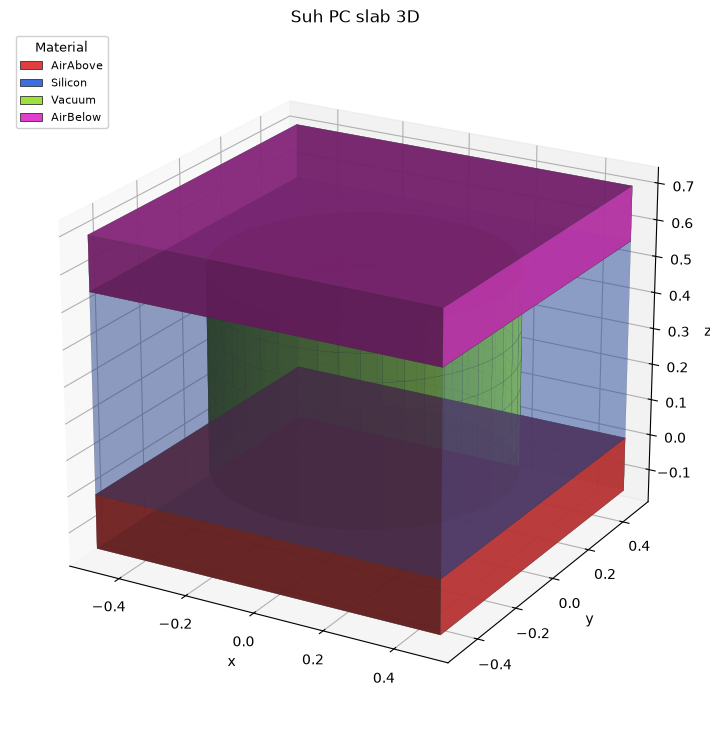

T_min=1.113e-06 at f=0.5440; max|R+T-1|=3.30e-14


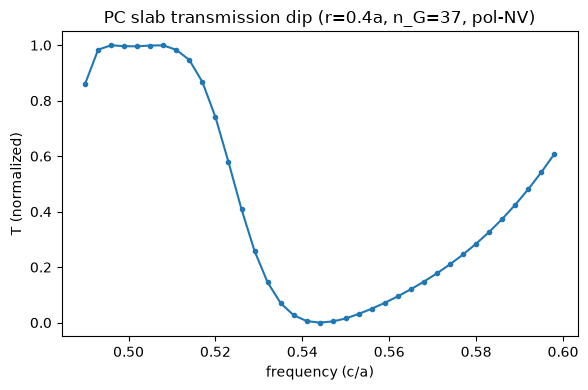

In [5]:
n_G = 37
air = mat_eps(1 + 0j, "Vacuum")
si = mat_eps(12 + 0j, "Silicon")
above = layer(1 + 0j, 0.0, "AirAbove")
slab = sim.layer_d(); slab.background_material = si; slab.depth = 0.55
slab.shapes = [sim.make_circle_shape_d(0.4, [0.0, 0.0], 0.0, air)]
slab.parent = [-1]
below = layer(1 + 0j, 0.0, "AirBelow")
layers = [above, slab, below]
show_stack_3d(layers, title="Suh PC slab 3D", cell=(-0.5, 0.5, -0.5, 0.5))

freqs = np.arange(0.49, 0.6001, 0.003)
T, R = [], []
for f in freqs:
    wl = 1.0 / float(f)
    inc, back = sim.rcwa_poynting_flux_d(layers, wl, n_G=n_G, pol="s", which_layer=0, use_pol_nv=True)
    fwd, _ = sim.rcwa_poynting_flux_d(layers, wl, n_G=n_G, pol="s", which_layer=2, use_pol_nv=True)
    T.append(float(np.real(fwd / inc)))
    R.append(float(np.real(-back / inc)))
T, R = np.asarray(T), np.asarray(R)
f_dip = float(freqs[int(np.argmin(T))])
print(f"T_min={T.min():.3e} at f={f_dip:.4f}; max|R+T-1|={np.max(np.abs(R+T-1)):.2e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(freqs, T, "C0-o", ms=3)
ax.set_xlabel("frequency (c/a)")
ax.set_ylabel("T (normalized)")
ax.set_title(rf"PC slab transmission dip (r=0.4a, n_G={n_G}, pol-NV)")
fig.tight_layout()
plt.show()



![Suh_APL_82_1999_2003](resources/Suh_APL_82_1999_2003.png)  
DOI: [10.1063/1.1563739](https://doi.org/10.1063/1.1563739)  
文献 Fig. 2(a)：文献先给出单层板基线：大孔径孔板在法向入射下出现接近零的透射谷，作为后续双层位移传感的物理起点。


核对：透射谷底约在 \(f\approx 0.54\)；打印项 \(\max|R+T-1|\) 应接近 0（pol-NV）。


## 5. 矩形介电岛上的共振透射（Tikhodeev 结构）


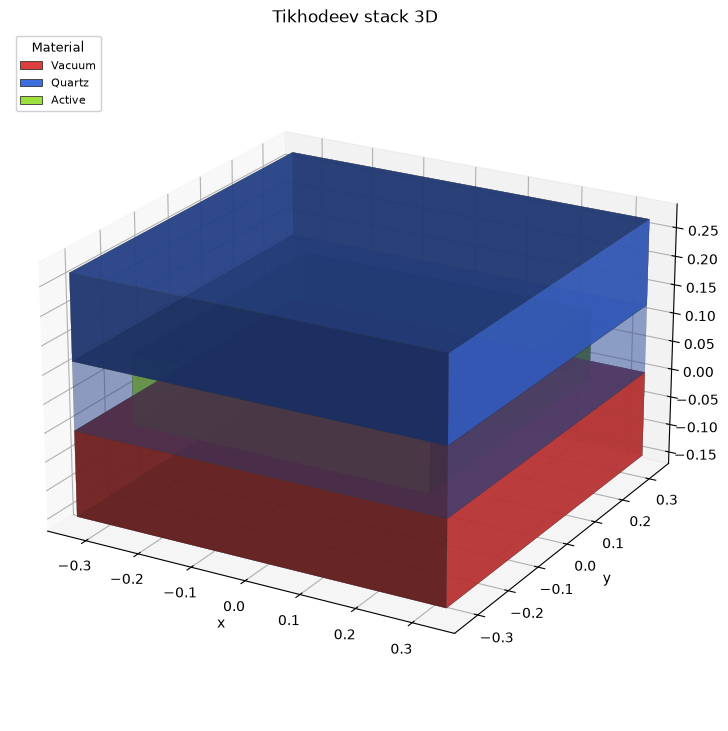

n_min=5, resonance depth~0.245


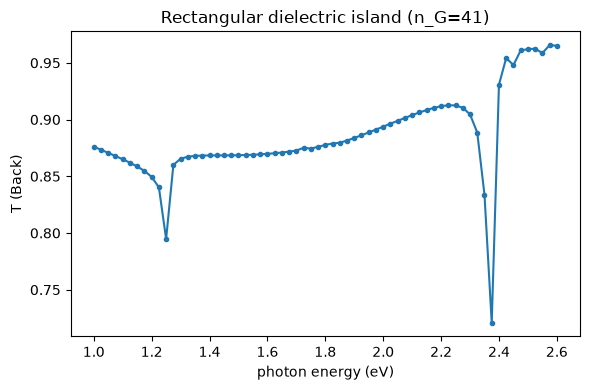

In [6]:
n_G = 41
vac = mat_eps(1 + 0j, "Vacuum")
quartz = mat_eps(2.132 + 0j, "Quartz")
active = mat_eps(3.97 + 0j, "Active")
front = sim.layer_d(); front.background_material = vac; front.depth = 0.0
slab = sim.layer_d(); slab.background_material = quartz; slab.depth = 0.12
hw = 0.4 * 0.68
slab.shapes = [sim.make_rect_shape_d([hw, hw], [0.0, 0.0], 0.0, active)]
slab.parent = [-1]
back = sim.layer_d(); back.background_material = quartz; back.depth = 0.0
layers = [front, slab, back]
p = 0.68
show_stack_3d(layers, title="Tikhodeev stack 3D", cell=(-p / 2, p / 2, -p / 2, p / 2))

Lr = [0.68, 0.0, 0.0, 0.68]
evs = np.arange(1.0, 2.6001, 0.025)
scale = 0.8065548889615557
T = np.array([
    float(np.real(sim.rcwa_poynting_flux_d(
        layers, 1.0 / (scale * float(ev)), n_G=n_G, Lr=Lr, pol="s",
        which_layer=2, use_pol_nv=True,
    )[0]))
    for ev in evs
])
mins = local_minima(T)
depth = float(T.max() - T[mins].min()) if mins else 0.0
print(f"n_min={len(mins)}, resonance depth~{depth:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(evs, T, "C0-o", ms=3)
ax.set_xlabel("photon energy (eV)")
ax.set_ylabel("T (Back)")
ax.set_title(rf"Rectangular dielectric island (n_G={n_G})")
fig.tight_layout()
plt.show()



![Tikhodeev_PRB_66_045102_2002](resources/Tikhodeev_PRB_66_045102_2002.png)  
DOI: [10.1103/PhysRevB.66.045102](https://doi.org/10.1103/PhysRevB.66.045102)  
文献 Fig. 4：文献用该透射谱说明：缓变背景上的尖谷对应准导模（及衍射阈值）被激发，并展示散射矩阵算法快速收敛。


核对：横轴为光子能量（eV）；在缓变背景上找局部透射谷，记录谷深即可。


## 6. 复频率平面上的准正规模（平板极点）


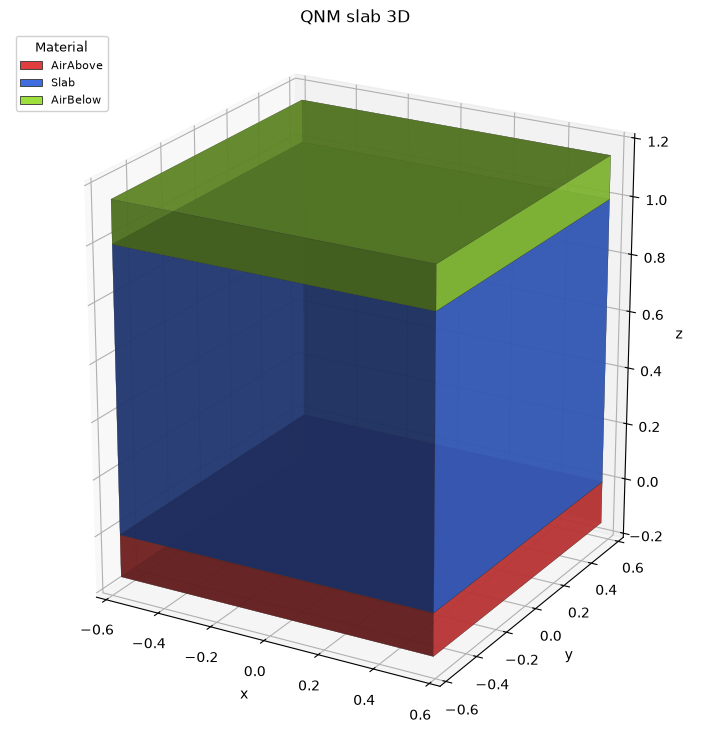

analytic: [(0.25+0.08742478814151496j), (0.5+0.08742478814151496j), (0.75+0.08742478814151496j), (1+0.08742478814151496j)]
N_roots : [(0.2499999999999999+0.08742478814151496j), (0.49999999999999983+0.08742478814151461j), (0.7499999999999998+0.08742478814151519j), (0.9999999999999996+0.08742478814151461j)]


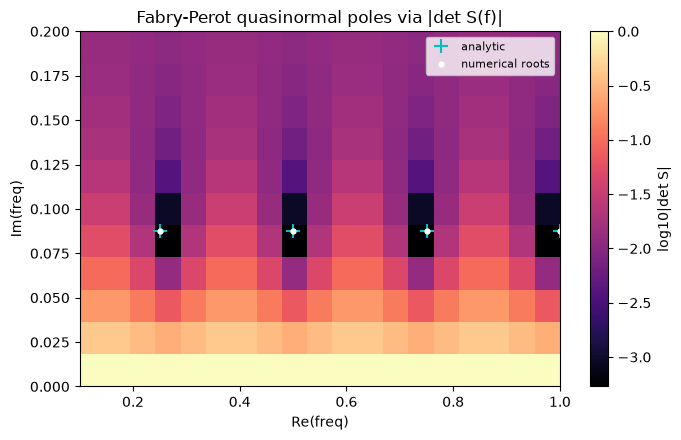

In [7]:
layers = [
    layer(1 + 0j, 0.0, "AirAbove"),
    layer(4 + 0j, 1.0, "Slab"),
    layer(1 + 0j, 0.0, "AirBelow"),
]
show_stack_3d(layers, title="QNM slab 3D")

imag_pole = fp_pole_imag()
poles_analytic = [m / 4.0 + 1j * imag_pole for m in range(1, 5)]

fr = np.arange(0.1, 1.001, 0.05)
fi = np.arange(0.0, 0.2001, 0.02)
mag = np.zeros((len(fi), len(fr)))
for i, y in enumerate(fi):
    for j, x in enumerate(fr):
        f = complex(float(x), float(y))
        mag[i, j] = abs(complex(sim.rcwa_det_s_d(layers, 1.0 / f, n_G=1)))

poles_num = [
    complex(p)
    for p in sim.rcwa_find_poles_d(
        layers, n_G=1, n_roots=4,
        bottom_left=complex(0.05, 0.01),
        top_right=complex(1.05, 0.15),
    )
]
print("analytic:", poles_analytic)
print("N_roots :", poles_num)

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    np.log10(mag + 1e-30), origin="lower", aspect="auto",
    extent=[fr[0], fr[-1], fi[0], fi[-1]], cmap="magma",
)
fig.colorbar(im, ax=ax, label=r"log10|det S|")
ax.plot([p.real for p in poles_analytic], [p.imag for p in poles_analytic],
        "c+", ms=10, mew=1.5, label="analytic")
ax.plot([z.real for z in poles_num], [z.imag for z in poles_num],
        "w.", ms=7, label="numerical roots")
ax.set_xlabel("Re(freq)")
ax.set_ylabel("Im(freq)")
ax.set_title(r"Fabry-Perot quasinormal poles via |det S(f)|")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


核对：\(\lvert\det S\rvert\) 最暗处为极点；青十字为解析、白点为数值求根，应对齐且 \(\mathrm{Im}\,f>0\)。


## 7. 衍射效率随傅里叶阶数的收敛（Li Cell A）


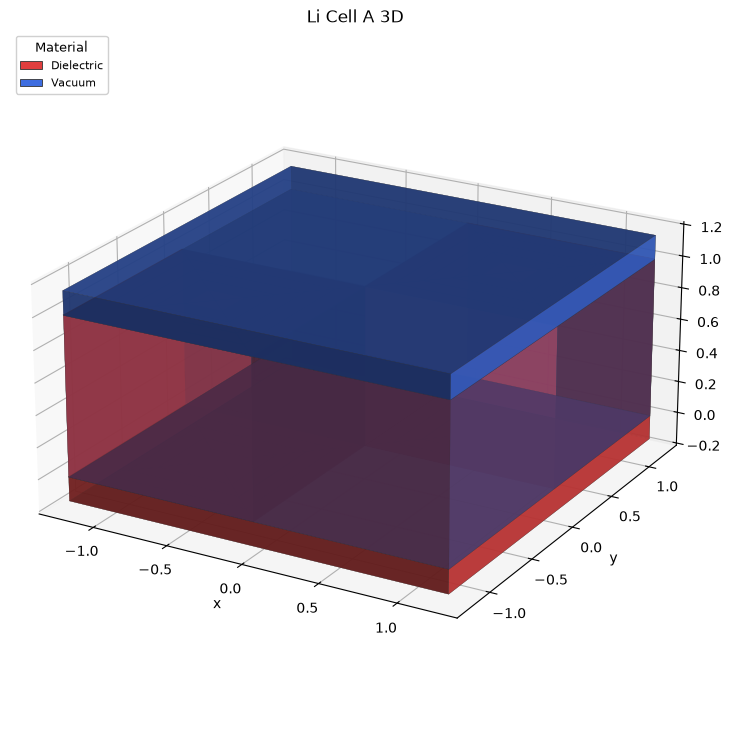

n_G=21, Plane wave orders=21, G=(1,1) eff=0.144218
n_G=41, Plane wave orders=37, G=(1,1) eff=0.120205
n_G=61, Plane wave orders=61, G=(1,1) eff=0.125240


n_G=81, Plane wave orders=81, G=(1,1) eff=0.125862


n_G=101, Plane wave orders=101, G=(1,1) eff=0.125971


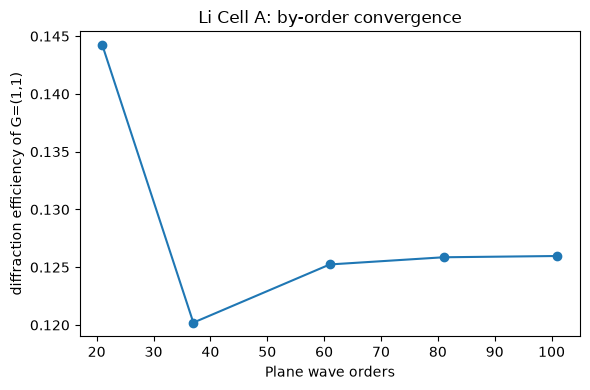

In [8]:
diel = mat_eps(2.25 + 0j, "Dielectric")
vac = mat_eps(1 + 0j, "Vacuum")
sidelen = 1.25
L = sidelen * 2
before = sim.layer_d(); before.background_material = diel; before.depth = 0.0
slab = sim.layer_d(); slab.background_material = vac; slab.depth = 1.0
hw = 0.5 * sidelen
slab.shapes = [
    sim.make_rect_shape_d([hw, hw], [-0.5 * sidelen, -0.5 * sidelen], 0.0, diel),
    sim.make_rect_shape_d([hw, hw], [0.5 * sidelen, 0.5 * sidelen], 0.0, diel),
]
slab.parent = [-1, -1]
after = sim.layer_d(); after.background_material = vac; after.depth = 0.0
layers = [before, slab, after]
show_stack_3d(layers, title="Li Cell A 3D", cell=(-L / 2, L / 2, -L / 2, L / 2))

Lr = [L, 0.0, 0.0, L]
ngs = [21, 41, 61, 81, 101]
eff, actual = [], []
for ng in ngs:
    inc, _ = sim.rcwa_poynting_flux_d(layers, 1.0, n_G=ng, Lr=Lr, pol="s", which_layer=0, use_pol_nv=True)
    fwd, _bwd, G = sim.rcwa_poynting_by_order_d(layers, 1.0, n_G=ng, Lr=Lr, pol="s", which_layer=2, use_pol_nv=True)
    idx = next(i for i, g in enumerate(G) if tuple(g) == (1, 1))
    actual.append(len(G))
    e = float(np.real(fwd[idx])) / max(float(np.real(inc)), 1e-30)
    eff.append(e)
    print(f"n_G={ng}, Plane wave orders={len(G)}, G=(1,1) eff={e:.6f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(actual, eff, "C0-o")
ax.set_xlabel("Plane wave orders")
ax.set_ylabel("diffraction efficiency of G=(1,1)")
ax.set_title("Li Cell A: by-order convergence")
fig.tight_layout()
plt.show()



![Li_JOSAA_14_2758_1997](resources/Li_JOSAA_14_2758_1997.png)  
DOI: [10.1364/JOSAA.14.002758](https://doi.org/10.1364/JOSAA.14.002758)  
文献 Fig. 5–6：文献用棋盘格 Cell A 证明：正确的 Fourier 因式分解使衍射效率随截断阶数快速收敛到稳定值。


核对：\(G=(1,1)\) 衍射效率随 NumG 升高应趋于约 \(0.12\)–\(0.13\)。


## 8. 双层光栅之间的光力随横向错位（Liu 结构）


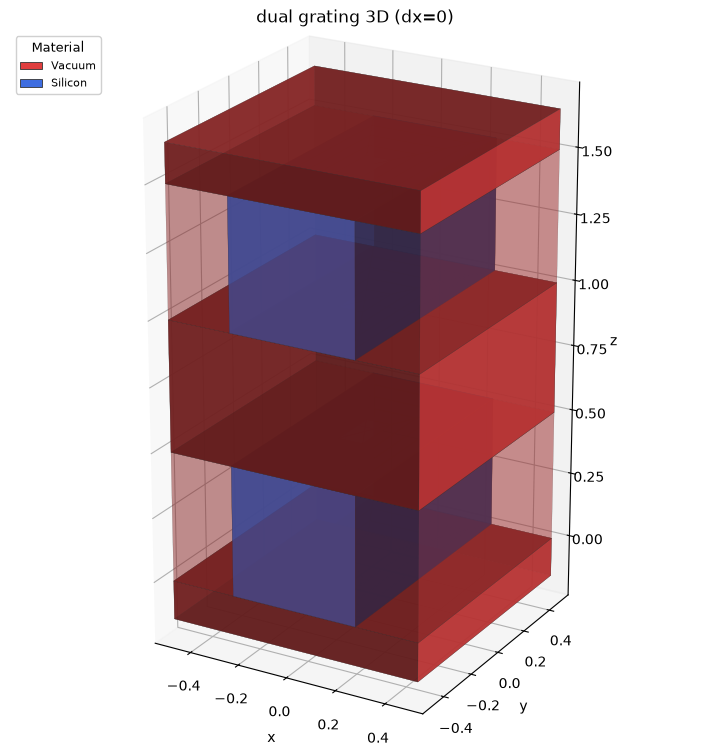

Fz mean=0.3260, span=0.0445; max|Fx|=0.0039


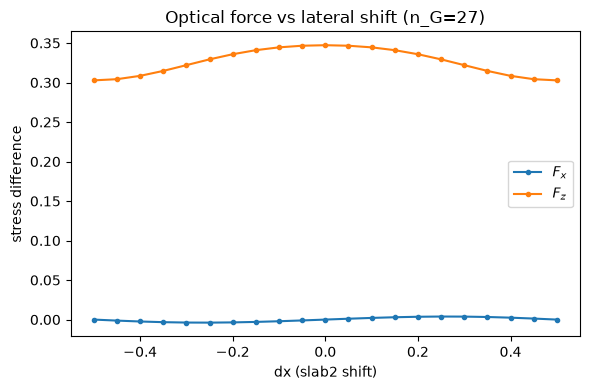

In [9]:
n_G = 27
vac = mat_eps(1 + 0j, "Vacuum")
si = mat_eps(12 + 0j, "Silicon")
above = sim.layer_d(); above.background_material = vac; above.depth = 0.0
slab = sim.layer_d(); slab.background_material = vac; slab.depth = 0.5
slab.shapes = [sim.make_rect_shape_d([0.25, 0.5], [0.0, 0.0], 0.0, si)]
slab.parent = [-1]
spacer = sim.layer_d(); spacer.background_material = vac; spacer.depth = 0.5
slab2 = sim.layer_d(); slab2.background_material = vac; slab2.depth = 0.5
slab2.shapes = [sim.make_rect_shape_d([0.25, 0.5], [0.0, 0.0], 0.0, si)]
slab2.parent = [-1]
below = sim.layer_d(); below.background_material = vac; below.depth = 0.0
layers_vis = [above, slab, spacer, slab2, below]
show_stack_3d(layers_vis, title="dual grating 3D (dx=0)", cell=(-0.5, 0.5, -0.5, 0.5))

Lr = [1.0, 0.0, 0.0, 0.0]
dxs = np.arange(-0.5, 0.5001, 0.05)
Fx, Fz = [], []
for dx in dxs:
    above = sim.layer_d(); above.background_material = vac; above.depth = 0.0
    slab = sim.layer_d(); slab.background_material = vac; slab.depth = 0.5
    slab.shapes = [sim.make_rect_shape_d([0.25, 0.5], [0.0, 0.0], 0.0, si)]
    slab.parent = [-1]
    spacer = sim.layer_d(); spacer.background_material = vac; spacer.depth = 0.5
    slab2 = sim.layer_d(); slab2.background_material = vac; slab2.depth = 0.5
    slab2.shapes = [sim.make_rect_shape_d([0.25, 0.5], [float(dx), 0.0], 0.0, si)]
    slab2.parent = [-1]
    below = sim.layer_d(); below.background_material = vac; below.depth = 0.0
    layers = [above, slab, spacer, slab2, below]
    t1 = sim.rcwa_stress_tensor_d(layers, 1.0 / 0.57, n_G=n_G, Lr=Lr, pol="p", which_layer=2, z_offset=0.5)
    t2 = sim.rcwa_stress_tensor_d(layers, 1.0 / 0.57, n_G=n_G, Lr=Lr, pol="p", which_layer=4, z_offset=0.0)
    Fx.append(float(np.real(t2[0] - t1[0])))
    Fz.append(float(np.real(t2[2] - t1[2])))
Fx, Fz = np.asarray(Fx), np.asarray(Fz)
print(f"Fz mean={Fz.mean():.4f}, span={Fz.max()-Fz.min():.4f}; max|Fx|={np.max(np.abs(Fx)):.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(dxs, Fx, "C0-o", ms=3, label=r"$F_x$")
ax.plot(dxs, Fz, "C1-o", ms=3, label=r"$F_z$")
ax.set_xlabel("dx (slab2 shift)")
ax.set_ylabel("stress difference")
ax.set_title(rf"Optical force vs lateral shift (n_G={n_G})")
ax.legend()
fig.tight_layout()
plt.show()



![Liu_OE_17_21897_2009](resources/Liu_OE_17_21897_2009.png)  
DOI: [10.1364/OE.17.021897](https://doi.org/10.1364/OE.17.021897)  
文献 Fig. 2(a)：文献离共振图说明：横向错位下 \(F_x\) 奇对称、\(F_z\) 偶对称，对称点为稳定/不稳定平衡。纵轴论文为 Force\((I_0/c)\)（按入射能流归一）；本算例绘制原始应力差 \(T_2-T_1\)，故绝对刻度不必与文献一致，重点看对称性与峰位。


核对：\(F_z(dx)\) 对 \(dx=0\) 偶对称且峰值在对齐处；\(\lvert F_x\rvert\) 应接近 0。


## 9. 色散金属半空间：反射与辐射压力


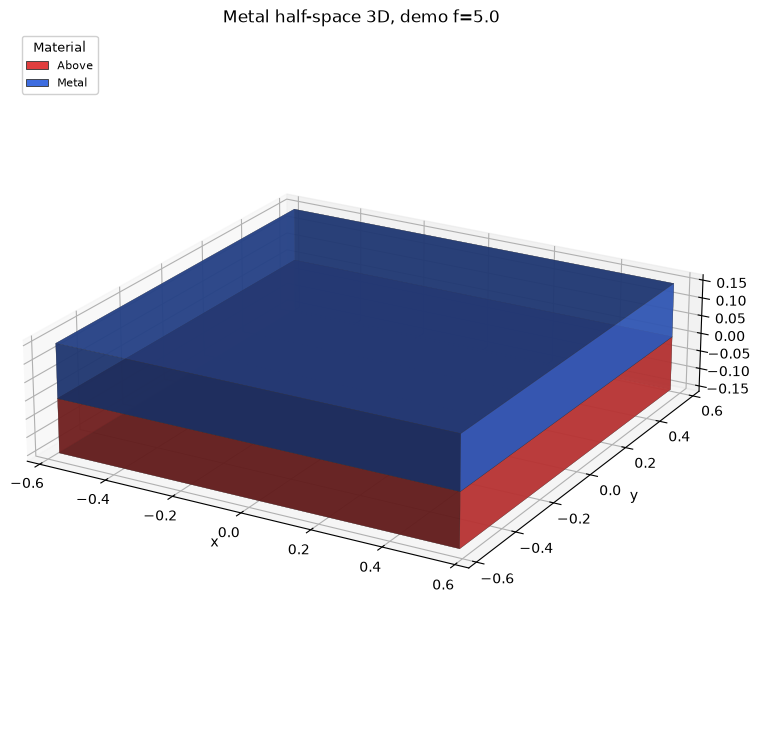

R(low f)~0.986, R(high f)~0.022


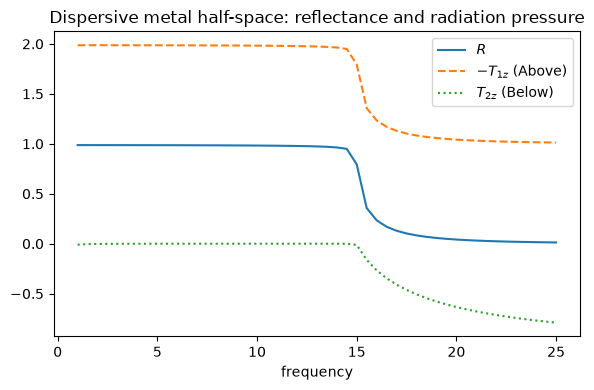

In [10]:
f_demo = 5.0
f_p, gamma = 15.0, 0.1
epsr = 1 - f_p * f_p / (f_demo * f_demo + gamma * gamma)
epsi = f_p * f_p / (f_demo * f_demo + gamma * gamma) * gamma / f_demo
layers_vis = [layer(1 + 0j, 0.0, "Above"), layer(complex(epsr, epsi), 0.0, "Metal")]
show_stack_3d(layers_vis, title=f"Metal half-space 3D, demo f={f_demo}")

freqs = np.arange(1.0, 25.001, 0.5)
R, T1z, T2z = [], [], []
for f in freqs:
    epsr = 1 - f_p * f_p / (f * f + gamma * gamma)
    epsi = f_p * f_p / (f * f + gamma * gamma) * gamma / f
    layers = [layer(1 + 0j, 0.0, "Above"), layer(complex(epsr, epsi), 0.0, "Metal")]
    wl = 1.0 / float(f)
    inc, back = sim.rcwa_poynting_flux_d(layers, wl, n_G=1, pol="s", which_layer=0)
    R.append(float(np.real(-back / inc)))
    t1 = sim.rcwa_stress_tensor_d(layers, wl, n_G=1, pol="s", which_layer=0)
    t2 = sim.rcwa_stress_tensor_d(layers, wl, n_G=1, pol="s", which_layer=1)
    T1z.append(-float(np.real(t1[2])))
    T2z.append(float(np.real(t2[2])))
R = np.asarray(R)
print(f"R(low f)~{R[freqs < 5].mean():.3f}, R(high f)~{R[freqs > 20].mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(freqs, R, "C0-", label="$R$")
ax.plot(freqs, T1z, "C1--", label=r"$-T_{1z}$ (Above)")
ax.plot(freqs, T2z, "C2:", label=r"$T_{2z}$ (Below)")
ax.set_xlabel("frequency")
ax.set_title("Dispersive metal half-space: reflectance and radiation pressure")
ax.legend()
fig.tight_layout()
plt.show()



![Antonoyiannakis_PRB_60_2361_1999](resources/Antonoyiannakis_PRB_60_2361_1999.png)  
DOI: [10.1103/PhysRevB.60.2361](https://doi.org/10.1103/PhysRevB.60.2361)  
文献 Fig. 1–2：文献用 Al 反射谱与辐射压说明：等离子体频率以下近似完美镜，入射侧压强约 \(2I/c\)；频率升高后反射下降、压力随之变化——校验 Maxwell 应力张量后处理。


核对：\(f\lesssim 15\)（等离子体频率以下）\(R\approx 1\)，入射侧 \(-\!T_{1z}\approx 2R\)；高于该频率后 \(R\) 下降。\(T_{1z},T_{2z}\) 是应力分量，不是透射功率。


## 10. 多样片元图案层：几何与闭式 FT→IFFT


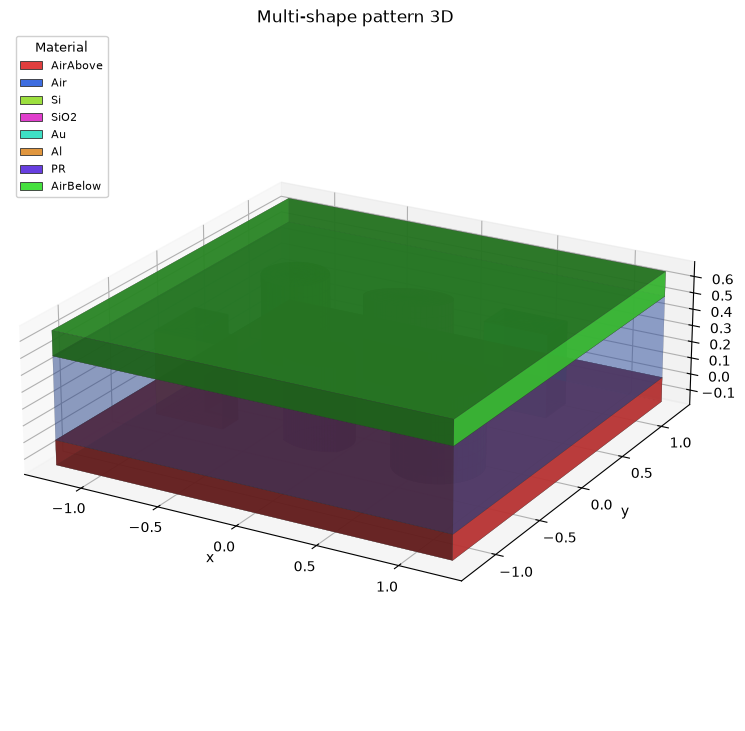

Re(eps) range [-57.80, 13.14]


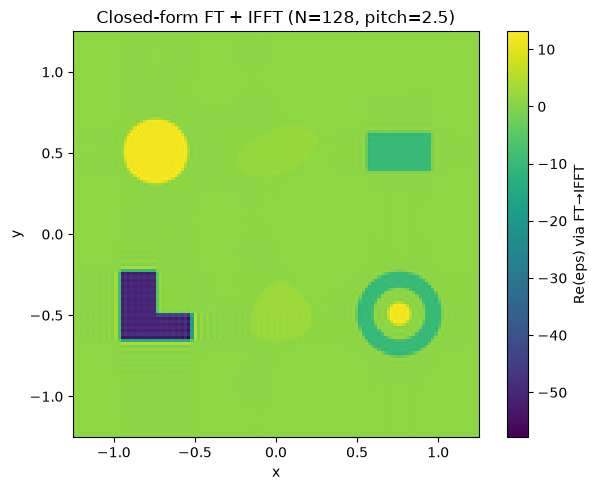

In [11]:
# Same multi-shape layout as tests/test_layer_visualizer.py::build_2d_shapes (double API).
# ε map: fourier_transform_mask (raster_layer_fourier_transform_d) → IFFT (test_rasterization).
def build_2d_shapes_d():
    si = mat_eps(12 + 0j, "Si")
    sio2 = mat_eps(2.1 + 0j, "SiO2")
    au = mat_eps(-10 + 1.5j, "Au")
    air = mat_eps(1 + 0j, "Air")
    al = mat_eps(-50 + 10j, "Al")
    pr = mat_eps(2.5 + 0.01j, "PR")
    grid = [(-0.75, 0.5), (0.0, 0.5), (0.75, 0.5), (-0.75, -0.5), (0.0, -0.5), (0.75, -0.5)]
    c0, c1, c2, c3, c4, c5 = grid
    p0, p1, p2 = [-0.16, -0.12], [0.18, -0.12], [0.02, 0.22]
    poly_verts = [
        [-0.22, -0.16], [0.22, -0.16], [0.22, 0.00],
        [0.00, 0.00], [0.00, 0.26], [-0.22, 0.26],
    ]
    return [
        sim.make_circle_shape_d(0.20, list(c0), 0.0, si),
        sim.make_ellipse_shape_d([0.26, 0.14], list(c1), 0.35, sio2),
        sim.make_rect_shape_d([0.20, 0.12], list(c2), 0.0, au),
        sim.make_poly_shape_d(poly_verts, list(c3), 0.0, al),
        sim.make_bezier_poly_2_shape_d(
            [[p0, [0.01, -0.22], p1], [p1, [0.28, 0.08], p2], [p2, [-0.20, 0.10], p0]],
            list(c4), 0.0, pr,
        ),
        sim.make_concentric_circles_shape_d([0.07, 0.16, 0.26], [si, air, au], list(c5), 0.0),
    ]

air = mat_eps(1 + 0j, "Air")
shapes = build_2d_shapes_d()
slab = sim.layer_d()
slab.background_material = air
slab.depth = 0.5
slab.shapes = shapes
slab.parent = [-1] * len(shapes)
layers_vis = [
    layer(1 + 0j, 0.0, "AirAbove"),
    slab,
    layer(1 + 0j, 0.0, "AirBelow"),
]
pitch = 2.5
cell = (-pitch / 2, pitch / 2, -pitch / 2, pitch / 2)
show_stack_3d(layers_vis, title="Multi-shape pattern 3D", cell=cell)

N, wl, NA = 128, 1.0, 1.0
grid = sim.grid_info_2d_d.create_bloch_mode_fourier(
    [N, N], wl, 0.0, NA,
    [[-pitch / 2, -pitch / 2], [pitch / 2, pitch / 2]],
)
spec = np.asarray(sim.raster_layer_fourier_transform_d(slab, grid, wl), dtype=np.complex128).reshape((N, N))
eps = (N * N) * np.fft.fftshift(np.fft.ifft2(spec))
print(f"Re(eps) range [{np.real(eps).min():.2f}, {np.real(eps).max():.2f}]")

fig, ax = plt.subplots(figsize=(6.5, 5.0))
im = ax.imshow(
    np.real(eps), origin="lower",
    extent=[cell[0], cell[1], cell[2], cell[3]], cmap="viridis",
)
fig.colorbar(im, ax=ax, label=r"Re(eps) via FT→IFFT")
ax.set_title(rf"Closed-form FT + IFFT (N={N}, pitch={pitch})")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()


核对：三维体应呈现六种片元；闭式 FT→IFFT 的 \(\mathrm{Re}\,\varepsilon\) 图中各材料区域应可辨认（金属可为负、介质为正）。
